In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/metroenergy_synthetic_dataset.csv')

In [ ]:
df.head()

,Timestamp,Household_ID,Region,Energy_Consumption_kWh,Voltage_V,Current_A,Solar_Generation_kWh,EV_Charging_kWh,Temperature_C,Humidity_Percent,Grid_Load_Percent,Fault_Flag,Maintenance_Status,Electricity_Cost_EUR
0,2025-01-01 00:00:00,H_0103,Cardiff,2.33,240.1,10.07,0.0,0.79,10.5,65.6,82.3,0,Normal,0.68
1,2025-01-01 01:00:00,H_0180,Birmingham,4.37,237.8,18.88,0.0,0.78,8.3,91.8,76.7,0,Normal,1.58
2,2025-01-01 02:00:00,H_0093,Manchester,3.12,233.0,13.19,0.0,0.00,5.5,73.5,78.5,0,Normal,0.80
3,2025-01-01 03:00:00,H_0015,Cardiff,3.50,239.6,14.38,0.0,0.20,10.1,54.0,71.2,0,Normal,1.10
4,2025-01-01 04:00:00,H_0107,Cardiff,5.59,241.1,22.78,0.0,0.00,11.0,97.5,85.1,0,Normal,1.73


In [ ]:
df.shape

(12000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               12000 non-null  object 
 1   Household_ID            12000 non-null  object 
 2   Region                  12000 non-null  object 
 3   Energy_Consumption_kWh  12000 non-null  float64
 4   Voltage_V               12000 non-null  float64
 5   Current_A               12000 non-null  float64
 6   Solar_Generation_kWh    12000 non-null  float64
 7   EV_Charging_kWh         12000 non-null  float64
 8   Temperature_C           12000 non-null  float64
 9   Humidity_Percent        12000 non-null  float64
 10  Grid_Load_Percent       12000 non-null  float64
 11  Fault_Flag              12000 non-null  int64  
 12  Maintenance_Status      12000 non-null  object 
 13  Electricity_Cost_EUR    12000 non-null  float64
dtypes: float64(9), int64(1), object(4)
mem

In [ ]:
df.dtypes

,0
Timestamp,object
Household_ID,object
Region,object
Energy_Consumption_kWh,float64
Voltage_V,float64
Current_A,float64
Solar_Generation_kWh,float64
EV_Charging_kWh,float64
Temperature_C,float64
Humidity_Percent,float64


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Household_ID,0
Region,0
Energy_Consumption_kWh,0
Voltage_V,0
Current_A,0
Solar_Generation_kWh,0
EV_Charging_kWh,0
Temperature_C,0
Humidity_Percent,0


In [ ]:
df.describe()

,Energy_Consumption_kWh,Voltage_V,Current_A,Solar_Generation_kWh,EV_Charging_kWh,Temperature_C,Humidity_Percent,Grid_Load_Percent,Fault_Flag,Electricity_Cost_EUR
count,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,3.854581,239.01130,16.120707,1.106848,0.873378,8.945825,71.974958,64.696983,0.049250,1.234804
std,1.346728,2.98688,5.634971,1.451026,1.889114,6.059199,11.813918,14.582299,0.216399,0.457752
min,0.500000,226.40000,1.000000,0.000000,0.000000,-5.000000,30.000000,30.000000,0.000000,0.100000
25%,2.920000,237.00000,12.150000,0.000000,0.000000,4.700000,64.000000,54.700000,0.000000,0.920000
50%,3.840000,239.00000,16.090000,0.000000,0.000000,9.100000,72.100000,64.900000,0.000000,1.230000
75%,4.780000,241.00000,20.060000,2.170000,0.840000,13.225000,80.200000,74.700000,0.000000,1.550000
max,8.000000,251.90000,30.000000,6.870000,15.000000,25.000000,98.000000,95.000000,1.000000,2.980000


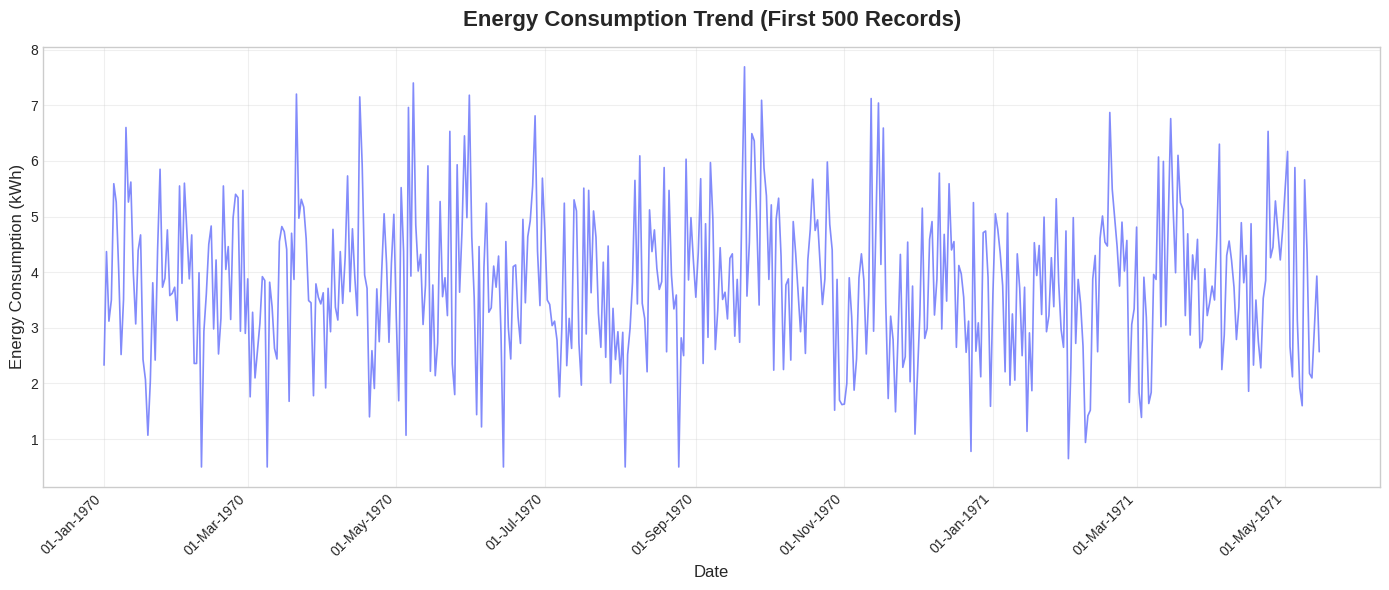

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(14, 6))

df_sample = df.head(500)

ax.plot(df_sample['Timestamp'],
        df_sample['Energy_Consumption_kWh'],
        color='#636EFA',
        linewidth=1.2,
        alpha=0.8)

ax.set_title('Energy Consumption Trend (First 500 Records)',
             fontsize=16, fontweight='bold', pad=15)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Energy Consumption (kWh)', fontsize=12)

# Show only dates on x-axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))

# Rotate date labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('Energy Consumption Trend (First 500 Records).png',
            dpi=1000,
            bbox_inches='tight')

plt.show()

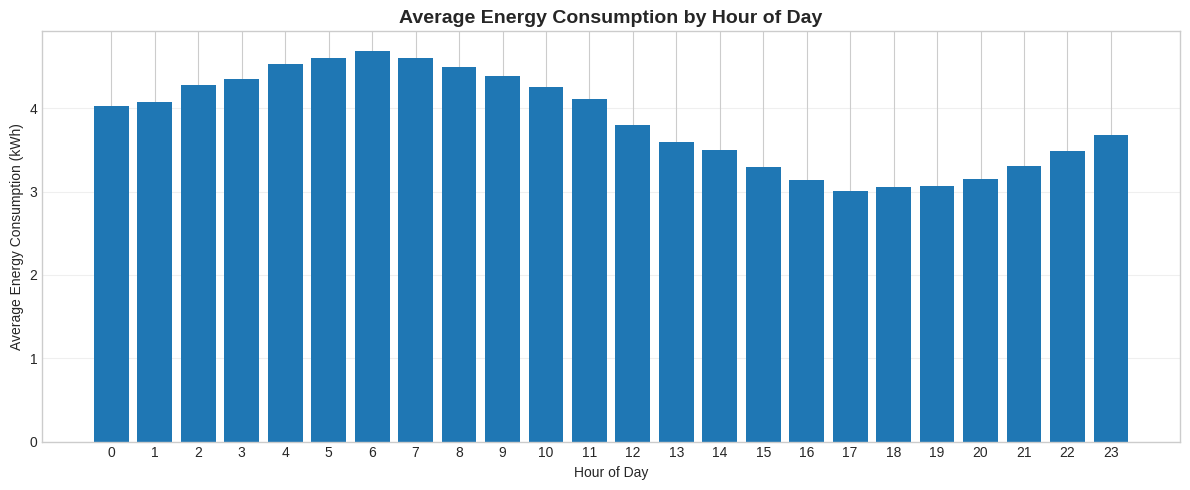

In [ ]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract hour
df['Hour'] = df['Timestamp'].dt.hour

# Calculate average energy consumption per hour
hourly_avg = df.groupby('Hour')['Energy_Consumption_kWh'].mean()

# Plot
plt.figure(figsize=(12,5))
plt.bar(hourly_avg.index, hourly_avg.values)

plt.title('Average Energy Consumption by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (kWh)')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Average Energy Consumption by Hour of Day.png', dpi=300, bbox_inches='tight')
plt.show()

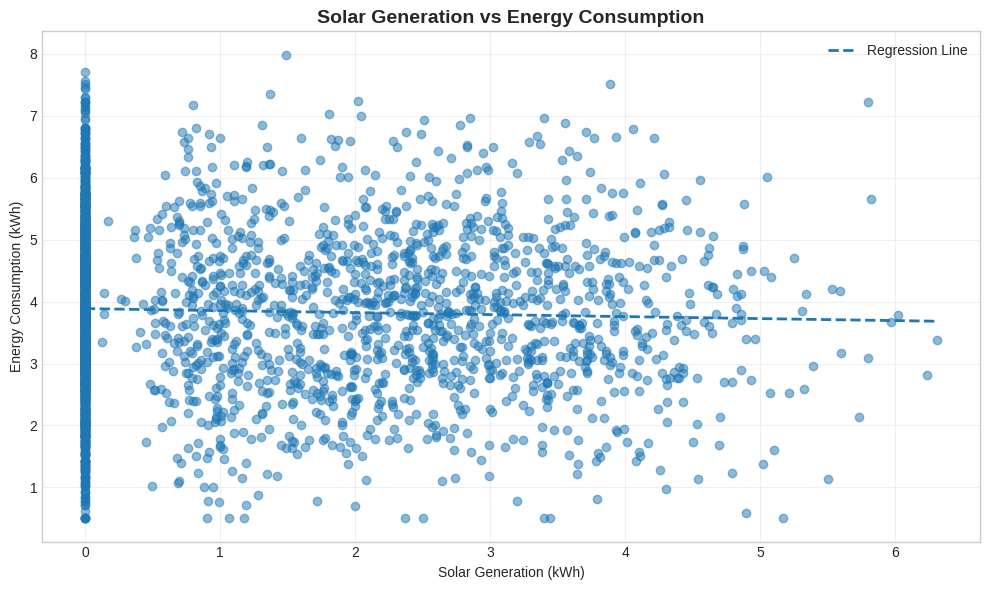

In [ ]:
import numpy as np

# FIGURE 4: Solar Generation vs Energy Consumption

sample_df = df.sample(n=3000, random_state=123)

plt.figure(figsize=(10, 6))

plt.scatter(sample_df['Solar_Generation_kWh'],
            sample_df['Energy_Consumption_kWh'],
            alpha=0.5)

# Add linear regression line
z = np.polyfit(sample_df['Solar_Generation_kWh'],
               sample_df['Energy_Consumption_kWh'], 1)

p = np.poly1d(z)

x_line = np.linspace(sample_df['Solar_Generation_kWh'].min(),
                     sample_df['Solar_Generation_kWh'].max(),
                     100)

plt.plot(x_line, p(x_line), linestyle='--', linewidth=2, label='Regression Line')

plt.title('Solar Generation vs Energy Consumption', fontsize=14, fontweight='bold')
plt.xlabel('Solar Generation (kWh)')
plt.ylabel('Energy Consumption (kWh)')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('fig4_solar_vs_consumption.png', dpi=1000, bbox_inches='tight')

plt.show()

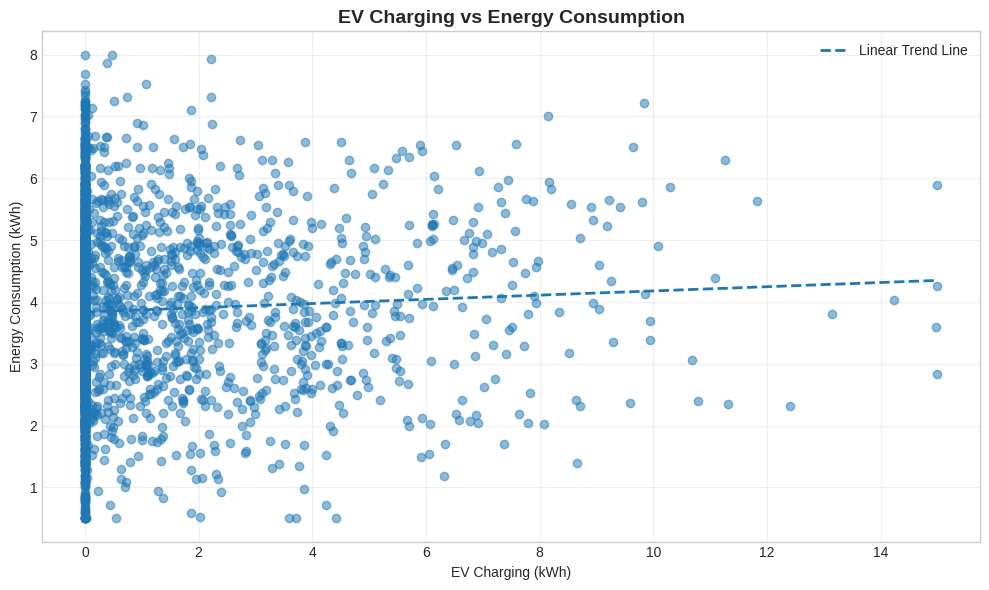

In [ ]:
sample_df = df.sample(n=3000, random_state=42)

plt.figure(figsize=(10, 6))

plt.scatter(sample_df['EV_Charging_kWh'],
            sample_df['Energy_Consumption_kWh'],
            alpha=0.5)

# Add linear trend line
z = np.polyfit(sample_df['EV_Charging_kWh'],
               sample_df['Energy_Consumption_kWh'], 1)

p = np.poly1d(z)

x_line = np.linspace(sample_df['EV_Charging_kWh'].min(),
                     sample_df['EV_Charging_kWh'].max(),
                     100)

plt.plot(x_line, p(x_line), linestyle='--', linewidth=2, label='Linear Trend Line')

plt.title('EV Charging vs Energy Consumption', fontsize=14, fontweight='bold')
plt.xlabel('EV Charging (kWh)')
plt.ylabel('Energy Consumption (kWh)')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('EV Charging vs Energy Consumption.png',
            dpi=1000,
            bbox_inches='tight')

plt.show()

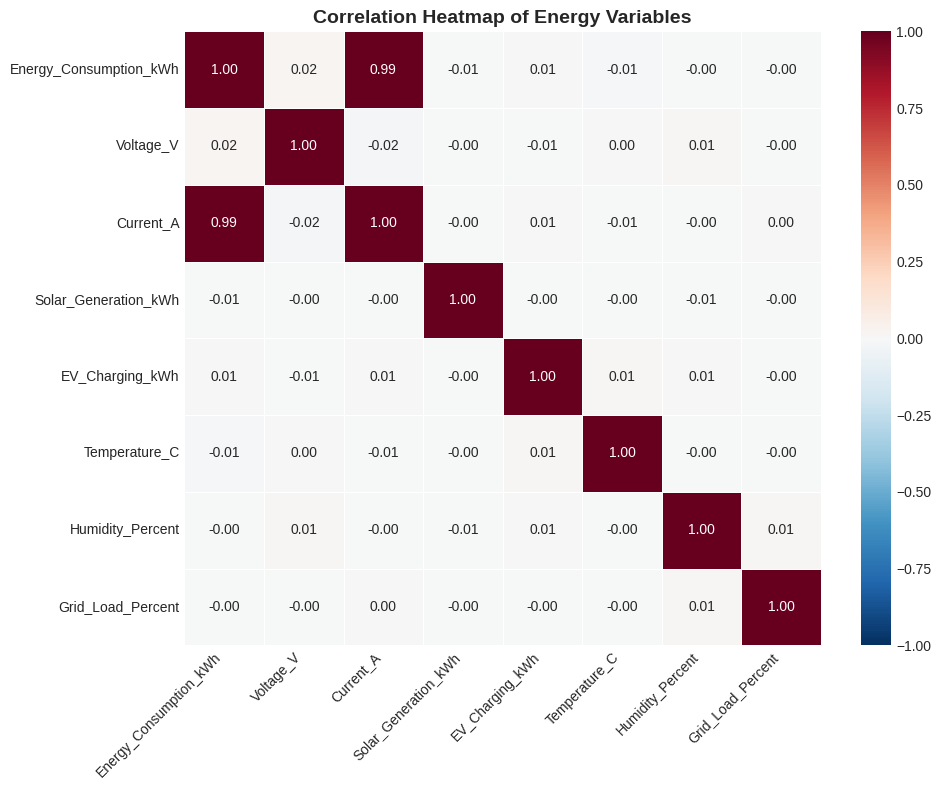

Figure 5 saved!


In [ ]:
numeric_cols = [
    'Energy_Consumption_kWh',
    'Voltage_V',
    'Current_A',
    'Solar_Generation_kWh',
    'EV_Charging_kWh',
    'Temperature_C',
    'Humidity_Percent',
    'Grid_Load_Percent'
]

# Calculate correlation
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt='.2f',           # 2 decimal places
    cmap='RdBu_r',       # Color scheme
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Energy Variables',
          fontsize=14,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig('fig5_correlation_heatmap.png',
            dpi=1000,
            bbox_inches='tight')

plt.show()

print("Figure 5 saved!")

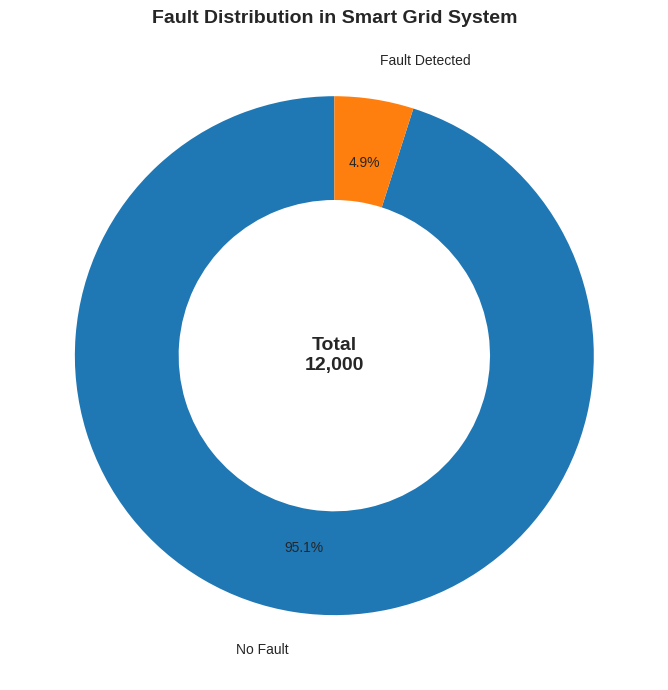

In [ ]:
# FIGURE 6: FAULT DISTRIBUTION (DONUT CHART)

fault_counts = df['Fault_Flag'].value_counts()

labels = ['No Fault', 'Fault Detected']
sizes = fault_counts.values

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    labeldistance=1.15,     # Move category labels outward
    pctdistance=0.75,       # Move percentage inside the donut
    wedgeprops={'width': 0.4}
)

# Center text
plt.text(0, 0, f'Total\n{len(df):,}',
         ha='center',
         va='center',
         fontsize=14,
         fontweight='bold')

plt.title('Fault Distribution in Smart Grid System',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()

plt.savefig('fig6_fault_distribution.png',
            dpi=1000,
            bbox_inches='tight')

plt.show()

In [ ]:
# Prepare features
df_ml = df.copy()
df_ml['Hour'] = df_ml['Timestamp'].dt.hour
df_ml['DayOfWeek'] = df_ml['Timestamp'].dt.dayofweek
df_ml['Month'] = df_ml['Timestamp'].dt.month

# Encode categorical variables
le_region = LabelEncoder()
df_ml['Region_encoded'] = le_region.fit_transform(df_ml['Region'])

le_maint = LabelEncoder()
df_ml['Maintenance_encoded'] = le_maint.fit_transform(df_ml['Maintenance_Status'])

# Select features for prediction
feature_cols = ['Voltage_V', 'Current_A', 'Solar_Generation_kWh', 'EV_Charging_kWh',
                'Temperature_C', 'Humidity_Percent', 'Grid_Load_Percent',
                'Hour', 'DayOfWeek', 'Region_encoded', 'Maintenance_encoded']

X = df_ml[feature_cols]
y = df_ml['Energy_Consumption_kWh']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n" + "=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print("=" * 60)




MODEL EVALUATION RESULTS
Mean Absolute Error (MAE): 0.0976
Root Mean Squared Error (RMSE): 0.1254
R2 Score: 0.9915


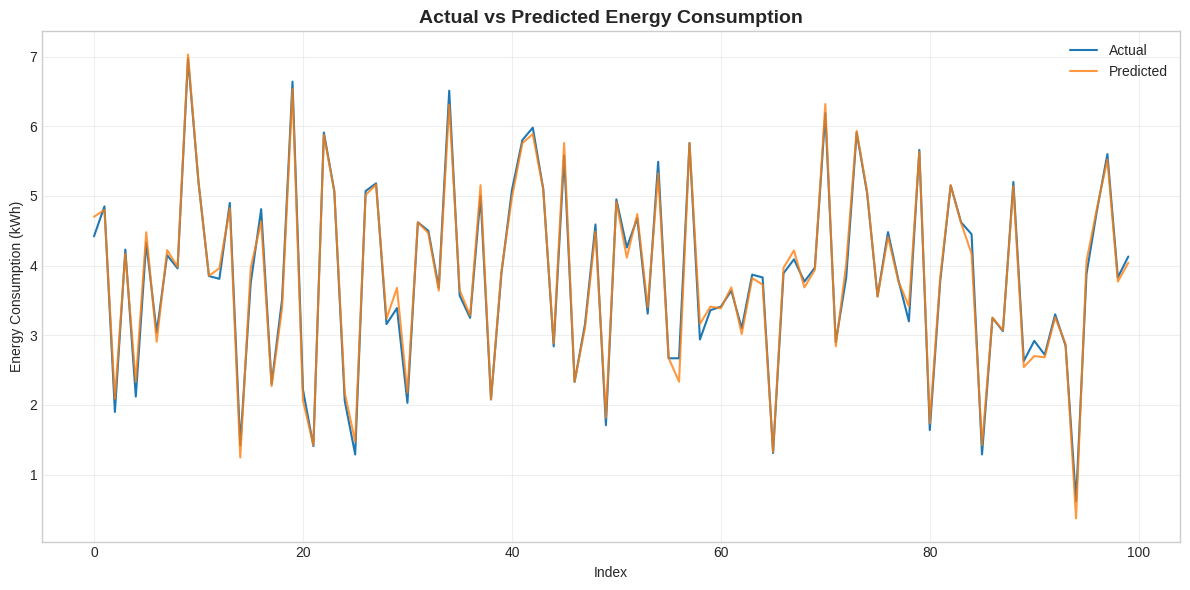

In [ ]:
# FIGURE 7: ACTUAL VS PREDICTED ENERGY CONSUMPTION

sample_idx = np.arange(100)

plt.figure(figsize=(12, 6))

plt.plot(sample_idx, y_test.values[:100],
         label='Actual',
         linewidth=1.5)

plt.plot(sample_idx, predictions[:100],
         label='Predicted',
         linewidth=1.5,
         alpha=0.8)

plt.title('Actual vs Predicted Energy Consumption',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Index')
plt.ylabel('Energy Consumption (kWh)')

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('fig7_actual_vs_predicted.png',
            dpi=1000,
            bbox_inches='tight')

plt.show()